In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import time
import copy
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms, models
from tqdm import tqdm
# Setup device for GPU usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
import warnings
warnings.filterwarnings('ignore')

In [2]:
# --- Sagittal Slice Extraction and Saving ---
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ========== Configuration ==========
nifti_root = 'D:/ADNI1_Complete 1Yr 1.5T'
output_dir = 'D:/ADNI_sagittal_slices'
num_best_slices = 5
# ===================================

os.makedirs(output_dir, exist_ok=True)

found_files = 0
processed_files = 0

for root, dirs, files in os.walk(nifti_root):
    print(f"[SCAN] Scanning: {root} — {len(files)} files")

    for file in files:
        if file.endswith('.nii') or file.endswith('.nii.gz'):
            found_files += 1
            nii_path = os.path.join(root, file)
            print(f"\n[INFO] Found file: {nii_path}")

            try:
                img = nib.load(nii_path)
                data = img.get_fdata()
                print(f"[INFO] Loaded shape: {data.shape}")

                # Sagittal view: slices along axis 0
                sagittal_data = data  # shape: (slices, height, width)
                print(f"[INFO] Sagittal view shape: {sagittal_data.shape}")

                # Normalize and convert to uint8
                sagittal_data = ((sagittal_data - np.min(sagittal_data)) /
                                 (np.max(sagittal_data) - np.min(sagittal_data)) * 255).astype(np.uint8)

                # Calculate variance for each sagittal slice
                variances = [np.var(sagittal_data[i, :, :]) for i in range(sagittal_data.shape[0])]
                print(f"[INFO] Variances (sample): {variances[len(variances)//2 - 2 : len(variances)//2 + 3]}")

                if all(v == 0 for v in variances):
                    print(f"[WARNING] All slice variances are 0 in {file}, skipping.")
                    continue

                best_indices = sorted(np.argsort(variances)[-num_best_slices:])
                print(f"[INFO] Best slice indices: {best_indices}")

                subject_id = os.path.basename(root)
                diagnosis = "Unknown"
                subject_output_path = os.path.join(output_dir, diagnosis)
                os.makedirs(subject_output_path, exist_ok=True)

                for i in best_indices:
                    slice_img = sagittal_data[i, :, :]
                    filename = f"{subject_id}_{file.replace('.nii', '').replace('.gz', '')}_sagittal{i}.png"
                    save_path = os.path.join(subject_output_path, filename)
                    plt.imsave(save_path, slice_img, cmap='gray')
                    print(f"[SAVED] {save_path}")

                processed_files += 1

            except Exception as e:
                print(f"[ERROR] Could not process {nii_path}: {e}")

print(f"\n[SUMMARY] Found {found_files} .nii files, processed {processed_files} files.")

[SCAN] Scanning: D:/ADNI1_Complete 1Yr 1.5T — 0 files
[SCAN] Scanning: D:/ADNI1_Complete 1Yr 1.5T\ADNI — 0 files
[SCAN] Scanning: D:/ADNI1_Complete 1Yr 1.5T\ADNI\002_S_0295 — 0 files
[SCAN] Scanning: D:/ADNI1_Complete 1Yr 1.5T\ADNI\002_S_0295\MPR__GradWarp__B1_Correction__N3__Scaled — 0 files
[SCAN] Scanning: D:/ADNI1_Complete 1Yr 1.5T\ADNI\002_S_0295\MPR__GradWarp__B1_Correction__N3__Scaled\2006-04-18_08_20_30.0 — 0 files
[SCAN] Scanning: D:/ADNI1_Complete 1Yr 1.5T\ADNI\002_S_0295\MPR__GradWarp__B1_Correction__N3__Scaled\2006-04-18_08_20_30.0\I45108 — 1 files

[INFO] Found file: D:/ADNI1_Complete 1Yr 1.5T\ADNI\002_S_0295\MPR__GradWarp__B1_Correction__N3__Scaled\2006-04-18_08_20_30.0\I45108\ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070319113623975_S13408_I45108.nii
[INFO] Loaded shape: (256, 256, 166)
[INFO] Sagittal view shape: (256, 256, 166)
[INFO] Variances (sample): [np.float64(1141.5875036239902), np.float64(1171.2773844779429), np.float64(1205.366553820032

In [3]:
# 2. Sort images by diagnosis using metadata CSV
import shutil
import pandas as pd

image_dir = "D:/ADNI_sagittal_slices/Unknown"
csv_path = "D:/ADNI1_Merged_MRI_Metadata.csv"
output_base = "D:/ADNI_sagittal_sorted"

df = pd.read_csv(csv_path)
df['Subject'] = df['Subject'].astype(str)
os.makedirs(output_base, exist_ok=True)
for group in ['AD', 'CN', 'MCI']:
    os.makedirs(os.path.join(output_base, group), exist_ok=True)
image_files = [f for f in os.listdir(image_dir) if f.endswith('.png')]
for img_file in tqdm(image_files, desc="Sorting Images"):
    parts = img_file.split('_')
    subj_id = "_".join(parts[2:5])
    match = df[df['Subject'] == subj_id]
    if not match.empty:
        group = match.iloc[0]['Group'].strip()
        if group in ['AD', 'CN', 'MCI']:
            src = os.path.join(image_dir, img_file)
            dst = os.path.join(output_base, group, img_file)
            shutil.copy2(src, dst)

Sorting Images: 100%|██████████| 11470/11470 [00:29<00:00, 383.96it/s]


In [4]:
import os
from collections import defaultdict

# Path to sorted folders
base_dir = "D:\ADNI_sagittal_sorted"
groups = ['AD', 'CN', 'MCI']

# Initialize counters
summary = defaultdict(lambda: {'files': 0, 'subjects': set()})

for group in groups:
    group_dir = os.path.join(base_dir, group)
    if not os.path.exists(group_dir):
        print(f"[WARNING] Folder not found: {group_dir}")
        continue

    files = [f for f in os.listdir(group_dir) if f.endswith('.png')]
    summary[group]['files'] = len(files)

    for f in files:
        parts = f.split('_')
        if len(parts) >= 5:
            subj_id = "_".join(parts[2:5])  # e.g., "002_S_1261"
            summary[group]['subjects'].add(subj_id)

# === Print Summary ===
for group in groups:
    print(f"\n📂 Group: {group}")
    print(f"   🖼️ Total image files: {summary[group]['files']}")
    print(f"   👤 Unique subjects: {len(summary[group]['subjects'])}")



📂 Group: AD
   🖼️ Total image files: 2380
   👤 Unique subjects: 133

📂 Group: CN
   🖼️ Total image files: 3525
   👤 Unique subjects: 195

📂 Group: MCI
   🖼️ Total image files: 5565
   👤 Unique subjects: 311


In [11]:
import os
import pandas as pd

root_dir = "D:\ADNI_sagittal_sorted"
data = []

for label in os.listdir(root_dir):
    label_path = os.path.join(root_dir, label)
    if os.path.isdir(label_path):
        for filename in os.listdir(label_path):
            if filename.endswith(".png"):
                subject_id = filename.split('_')[0]
                file_path = os.path.join(label_path, filename)
                data.append([file_path, label, subject_id])

df = pd.DataFrame(data, columns=["path", "label", "subject_id"])
df.to_csv("image_metadata.csv", index=False)


In [12]:

# Load the full dataset CSV
df = pd.read_csv('D:\image_metadata.csv')

print("Dataset Overview:")
print(f"Total images: {len(df)}")
print(f"Total subjects: {df['subject_id'].nunique()}")
print("\nClass distribution (images):")
print(df['label'].value_counts())

# CRITICAL: Subject-level splitting to prevent data leakage
subjects_df = df.groupby('subject_id')['label'].first().reset_index()
print(f"\nSubject-level class distribution:")
print(subjects_df['label'].value_counts())

# Split subjects (not images) to prevent leakage
train_subjects, temp_subjects = train_test_split(
    subjects_df, test_size=0.3, stratify=subjects_df['label'], random_state=42
)
val_subjects, test_subjects = train_test_split(
    temp_subjects, test_size=0.5, stratify=temp_subjects['label'], random_state=42
)

# Filter original dataframe based on subject splits
train_df = df[df['subject_id'].isin(train_subjects['subject_id'])].copy()
val_df = df[df['subject_id'].isin(val_subjects['subject_id'])].copy()
test_df = df[df['subject_id'].isin(test_subjects['subject_id'])].copy()

# Save splits
train_df.to_csv('D:\ADNI_train_subject_split.csv', index=False)
val_df.to_csv('D:\ADNI_val_subject_split.csv', index=False)
test_df.to_csv('D:\ADNI_test_subject_split.csv', index=False)

print(f"\n✅ Subject-level splits:")
print(f"Train: {len(train_subjects)} subjects, {len(train_df)} images")
print(f"Val: {len(val_subjects)} subjects, {len(val_df)} images")
print(f"Test: {len(test_subjects)} subjects, {len(test_df)} images")

# Check for subject leakage (should be empty)
train_subj_set = set(train_subjects['subject_id'])
val_subj_set = set(val_subjects['subject_id'])
test_subj_set = set(test_subjects['subject_id'])

leakage_train_val = train_subj_set.intersection(val_subj_set)
leakage_train_test = train_subj_set.intersection(test_subj_set)
leakage_val_test = val_subj_set.intersection(test_subj_set)

if not (leakage_train_val or leakage_train_test or leakage_val_test):
    print("✅ No subject leakage detected!")
else:
    print("⚠️ Subject leakage detected!")

Dataset Overview:
Total images: 11470
Total subjects: 2294

Class distribution (images):
label
MCI    5565
CN     3525
AD     2380
Name: count, dtype: int64

Subject-level class distribution:
label
MCI    1113
CN      705
AD      476
Name: count, dtype: int64

✅ Subject-level splits:
Train: 1605 subjects, 8025 images
Val: 344 subjects, 1720 images
Test: 345 subjects, 1725 images
✅ No subject leakage detected!


In [13]:
# Compute class weights to handle imbalanced data
label_map = {'AD': 0, 'CN': 1, 'MCI': 2}
train_labels = [label_map[label] for label in train_df['label']]

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.FloatTensor(class_weights)

print("Class weights for balanced training:")
for i, (label, weight) in enumerate(zip(['AD', 'CN', 'MCI'], class_weights)):
    print(f"{label}: {weight:.3f}")

Class weights for balanced training:
AD: 1.607
CN: 1.085
MCI: 0.687


Dataset sizes: Train=8025, Val=1720, Test=1725
Class weights: tensor([1.6066, 1.0852, 0.6868], device='cuda:0')

Epoch 1/10
--------------------


Train: 100%|██████████| 2007/2007 [01:02<00:00, 31.98it/s]


Train Loss: 1.0503 Acc: 0.5059 F1: 0.5087


Val: 100%|██████████| 430/430 [00:06<00:00, 63.25it/s]


Val Loss: 1.1048 Acc: 0.5041 F1: 0.5156

Epoch 2/10
--------------------


...

Val Loss: 2.4437 Acc: 0.6413 F1: 0.6396

Epoch 5/10
--------------------


Train: 100%|██████████| 2007/2007 [01:01<00:00, 32.38it/s]


Train Loss: 0.1059 Acc: 0.9748 F1: 0.9748


Val: 100%|██████████| 430/430 [00:06<00:00, 62.65it/s]


Val Loss: 3.3797 Acc: 0.5802 F1: 0.5774

Early stopping triggered after 5 epochs

Training complete in 5m 45s
Best Val Acc: 0.6413


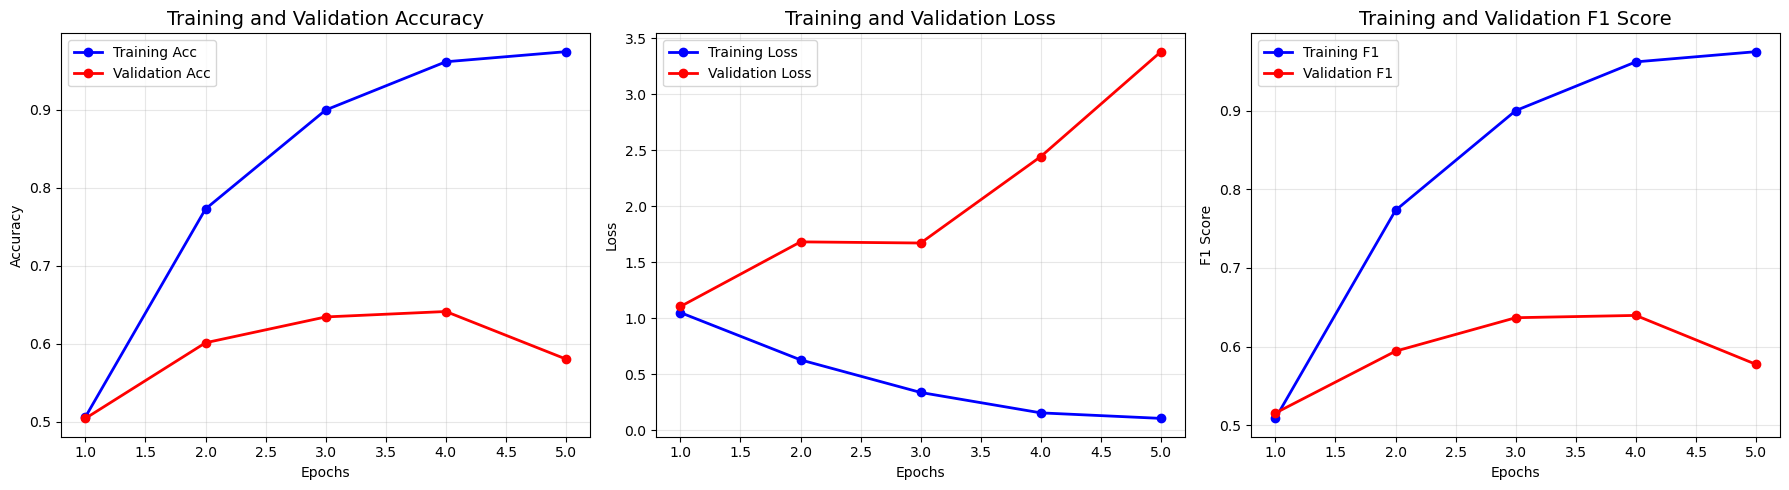

Evaluating Validation: 100%|██████████| 430/430 [00:07<00:00, 55.33it/s]



==================== VALIDATION SET - IMAGE LEVEL ====================
Total images evaluated: 1720

📊 Classification Report:
              precision    recall  f1-score   support

          AD     0.5181    0.4845    0.5007       355
          CN     0.6627    0.6302    0.6460       530
         MCI     0.6753    0.7150    0.6946       835

    accuracy                         0.6413      1720
   macro avg     0.6187    0.6099    0.6138      1720
weighted avg     0.6390    0.6413    0.6396      1720


🎯 Weighted Multi-class AUC (OvR): 0.7919

📈 Per-class AUC scores:
  AD: 0.7810
  CN: 0.8256
  MCI: 0.7752

🤝 Cohen's Kappa: 0.4218


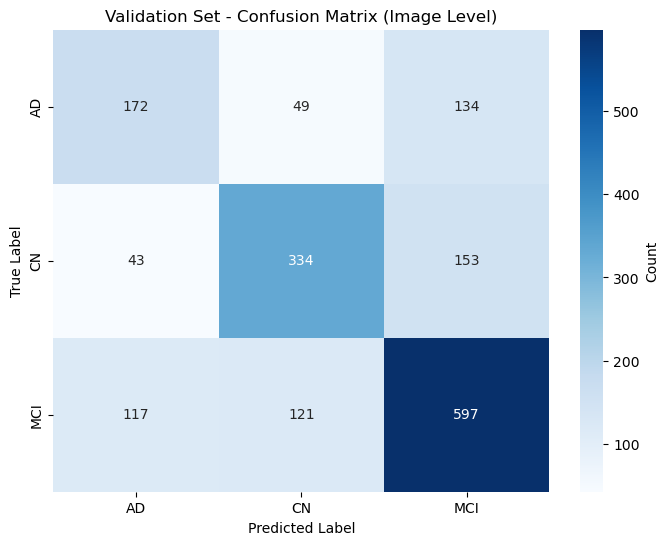


==================== VALIDATION SET - SUBJECT LEVEL ====================
Total subjects evaluated: 344

📊 Subject-Level Classification Report:
              precision    recall  f1-score   support

          AD     0.5484    0.4789    0.5113        71
          CN     0.6875    0.6226    0.6535       106
         MCI     0.6720    0.7485    0.7082       167

    accuracy                         0.6541       344
   macro avg     0.6360    0.6167    0.6243       344
weighted avg     0.6513    0.6541    0.6507       344


🎯 Subject-Level Weighted Multi-class AUC: 0.8079


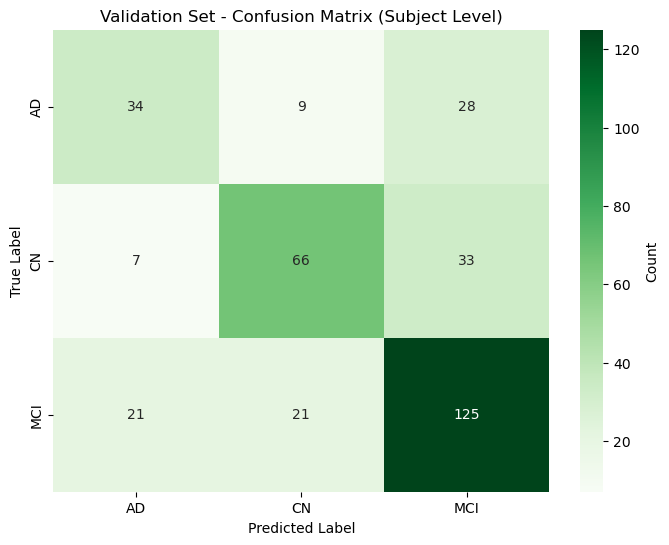

Evaluating Test: 100%|██████████| 432/432 [00:07<00:00, 56.06it/s]



==================== TEST SET - IMAGE LEVEL ====================
Total images evaluated: 1725

📊 Classification Report:
              precision    recall  f1-score   support

          AD     0.5489    0.5611    0.5549       360
          CN     0.6493    0.6113    0.6297       530
         MCI     0.6958    0.7150    0.7053       835

    accuracy                         0.6510      1725
   macro avg     0.6313    0.6291    0.6300      1725
weighted avg     0.6509    0.6510    0.6507      1725


🎯 Weighted Multi-class AUC (OvR): 0.8159

📈 Per-class AUC scores:
  AD: 0.8291
  CN: 0.8302
  MCI: 0.8012

🤝 Cohen's Kappa: 0.4424


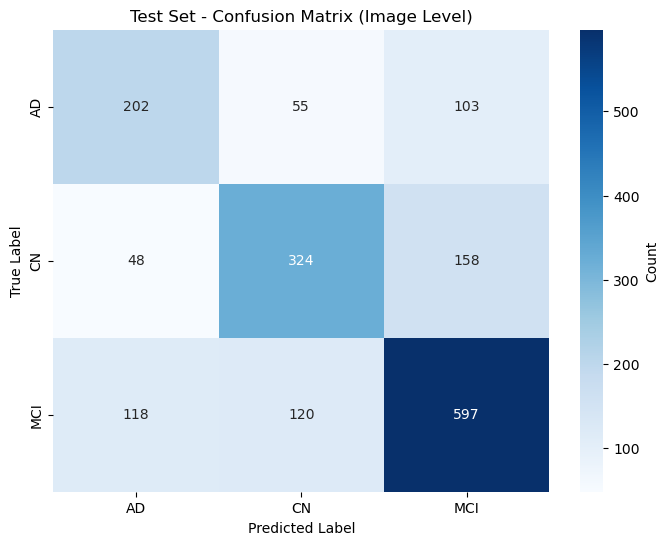


==================== TEST SET - SUBJECT LEVEL ====================
Total subjects evaluated: 345

📊 Subject-Level Classification Report:
              precision    recall  f1-score   support

          AD     0.5938    0.5278    0.5588        72
          CN     0.6667    0.5849    0.6231       106
         MCI     0.6809    0.7665    0.7211       167

    accuracy                         0.6609       345
   macro avg     0.6471    0.6264    0.6344       345
weighted avg     0.6583    0.6609    0.6571       345


🎯 Subject-Level Weighted Multi-class AUC: 0.8284


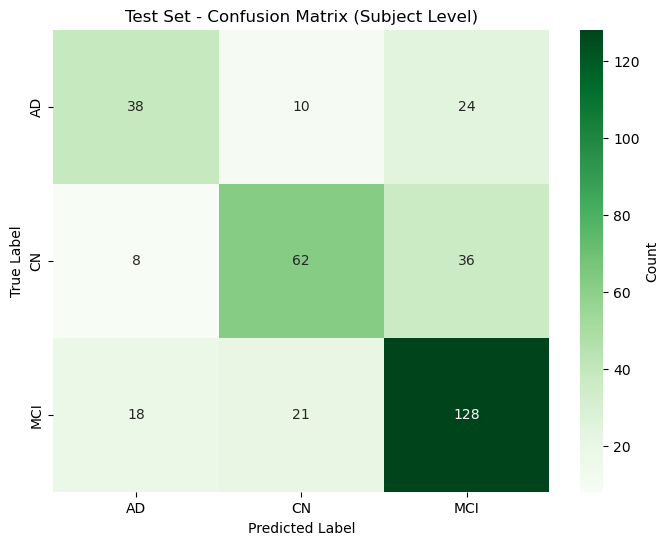

Image-level Confusion Matrix:
[[202  55 103]
 [ 48 324 158]
 [118 120 597]]

MCI images misclassified as AD: 118 (14.13%)
MCI images misclassified as CN: 120 (14.37%)
Total MCI images: 835
Subject-level Confusion Matrix:
[[ 38  10  24]
 [  8  62  36]
 [ 18  21 128]]

MCI subjects misclassified as AD: 18 (10.78%)
MCI subjects misclassified as CN: 21 (12.57%)
Total MCI subjects: 167

                    FINAL MODEL SUMMARY

📊 VALIDATION SET PERFORMANCE:
  Image-level Accuracy: 0.6413
  Subject-level Accuracy: 0.6541

🎯 TEST SET PERFORMANCE:
  Image-level Accuracy: 0.6510
  Subject-level Accuracy: 0.6609

💡 IMPROVEMENTS FROM BASELINE:
  Subject-level improvement: -0.0534

🔍 KEY ENHANCEMENTS IMPLEMENTED:
  ✅ Subject-level data splitting (prevents leakage)
  ✅ Class-weighted loss function (handles imbalance)
  ✅ Medical image-specific augmentations
  ✅ Enhanced model architecture with dropout
  ✅ Gradient clipping and early stopping
  ✅ Subject-level prediction aggregation
  ✅ Comprehensive

In [5]:
# code with no augmentatio and more no of epochs
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import time
import copy
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms, models
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Dataset Class ---
class MedicalImageDataset(Dataset):
    def __init__(self, csv_file, transform=None, return_subject_id=False):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.return_subject_id = return_subject_id
        self.label_map = {'AD': 0, 'CN': 1, 'MCI': 2}
        self.data['label'] = self.data['label'].map(self.label_map)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['path']
        label = self.data.iloc[idx]['label']
        subject_id = self.data.iloc[idx]['subject_id']
        image = Image.open(img_path).convert("L").convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.return_subject_id:
            return image, label, subject_id
        return image, label

# --- Transforms (NO AUGMENTATION) ---
plain_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Datasets & Dataloaders (subset) ---
train_dataset = MedicalImageDataset(
    csv_file='D:\\ADNI_train_subject_split.csv',
    transform=plain_transform,
    return_subject_id=True
)
val_dataset = MedicalImageDataset(
    csv_file='D:\\ADNI_val_subject_split.csv',
    transform=plain_transform,
    return_subject_id=True
)
test_dataset = MedicalImageDataset(
    csv_file='D:\\ADNI_test_subject_split.csv',
    transform=plain_transform,
    return_subject_id=True
)
batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
dataloaders = {'train': train_loader, 'val': val_loader}
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}
print(f"Dataset sizes: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

# --- Class Weights ---
label_map = {'AD': 0, 'CN': 1, 'MCI': 2}
train_labels = [label_map[label] for label in pd.read_csv('D:\ADNI_train_subject_split.csv')['label']]
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print("Class weights:", class_weights_tensor)

# --- Model ---
# --- Model: ResNet18 for 3-class MRI classification ---
from torchvision import models

num_classes = 3
model = models.resnet18(pretrained=True)
# Replace the final fully connected layer for 3 classes
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, num_classes)
)
model = model.to(device)

# --- Loss, Optimizer, Scheduler ---
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
# ...existing code...
optimizer = optim.AdamW(
    model.parameters(),  # Use all parameters for ResNet
    lr=1e-4,
    weight_decay=1e-4
)
# ...existing code...
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True, min_lr=1e-6
)

# --- Training Loop ---
def train_model_enhanced(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes,
                        device, num_epochs=2, early_stopping_patience=1):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    early_stopping_counter = 0
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print('-' * 20)
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []
            phase_loader = dataloaders[phase]
            for inputs, labels, _ in tqdm(phase_loader, desc=f"{phase.capitalize()}"):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} F1: {epoch_f1:.4f}")
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            history[f'{phase}_f1'].append(epoch_f1)
            if phase == 'val':
                scheduler.step(epoch_loss)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    early_stopping_counter = 0
                    torch.save(model.state_dict(), 'best_model.pth')
                else:
                    early_stopping_counter += 1
                if early_stopping_counter >= early_stopping_patience:
                    print(f"\nEarly stopping triggered after {epoch+1} epochs")
                    break
        if early_stopping_counter >= early_stopping_patience:
            break
    time_elapsed = time.time() - since
    print(f"\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best Val Acc: {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model, history

model, history = train_model_enhanced(
    model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, device,
    num_epochs=10, early_stopping_patience=1
)

# --- Visualization ---
def plot_enhanced_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(history['train_acc']) + 1)
    axes[0].plot(epochs, history['train_acc'], 'bo-', label='Training Acc', linewidth=2)
    axes[0].plot(epochs, history['val_acc'], 'ro-', label='Validation Acc', linewidth=2)
    axes[0].set_title('Training and Validation Accuracy', fontsize=14)
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history['train_loss'], 'bo-', label='Training Loss', linewidth=2)
    axes[1].plot(epochs, history['val_loss'], 'ro-', label='Validation Loss', linewidth=2)
    axes[1].set_title('Training and Validation Loss', fontsize=14)
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[2].plot(epochs, history['train_f1'], 'bo-', label='Training F1', linewidth=2)
    axes[2].plot(epochs, history['val_f1'], 'ro-', label='Validation F1', linewidth=2)
    axes[2].set_title('Training and Validation F1 Score', fontsize=14)
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('F1 Score')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_enhanced_training_history(history)

# --- Evaluation ---
def comprehensive_medical_evaluation(model, dataloader, class_names, dataset_name="Validation"):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    subject_predictions = {}
    with torch.no_grad():
        for inputs, labels, subject_ids in tqdm(dataloader, desc=f"Evaluating {dataset_name}"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            for i, subj_id in enumerate(subject_ids):
                if subj_id not in subject_predictions:
                    subject_predictions[subj_id] = {'probs': [], 'true_label': labels[i].item()}
                subject_predictions[subj_id]['probs'].append(probs[i].cpu().numpy())
    print(f"\n{'='*20} {dataset_name.upper()} SET - IMAGE LEVEL {'='*20}")
    print(f"Total images evaluated: {len(all_labels)}")
    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
    all_probs_array = np.array(all_probs)
    try:
        auc_ovr = roc_auc_score(all_labels, all_probs_array, multi_class='ovr', average='weighted')
        print(f"\n🎯 Weighted Multi-class AUC (OvR): {auc_ovr:.4f}")
        print("\n📈 Per-class AUC scores:")
        for i, class_name in enumerate(class_names):
            binary_labels = (np.array(all_labels) == i).astype(int)
            class_auc = roc_auc_score(binary_labels, all_probs_array[:, i])
            print(f"  {class_name}: {class_auc:.4f}")
    except:
        print("⚠️ Could not compute AUC (insufficient class representation)")
    kappa = cohen_kappa_score(all_labels, all_preds)
    print(f"\n🤝 Cohen's Kappa: {kappa:.4f}")
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names,
                cmap='Blues', cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{dataset_name} Set - Confusion Matrix (Image Level)')
    plt.show()
    print(f"\n{'='*20} {dataset_name.upper()} SET - SUBJECT LEVEL {'='*20}")
    subject_true_labels = []
    subject_pred_labels = []
    subject_avg_probs = []
    for subj_id, data in subject_predictions.items():
        avg_probs = np.mean(data['probs'], axis=0)
        pred_label = np.argmax(avg_probs)
        subject_true_labels.append(data['true_label'])
        subject_pred_labels.append(pred_label)
        subject_avg_probs.append(avg_probs)
    print(f"Total subjects evaluated: {len(subject_true_labels)}")
    print("\n📊 Subject-Level Classification Report:")
    print(classification_report(subject_true_labels, subject_pred_labels, target_names=class_names, digits=4))
    try:
        subject_avg_probs_array = np.array(subject_avg_probs)
        subject_auc = roc_auc_score(subject_true_labels, subject_avg_probs_array, multi_class='ovr', average='weighted')
        print(f"\n🎯 Subject-Level Weighted Multi-class AUC: {subject_auc:.4f}")
    except:
        print("⚠️ Could not compute subject-level AUC")
    subject_cm = confusion_matrix(subject_true_labels, subject_pred_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(subject_cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names,
                cmap='Greens', cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{dataset_name} Set - Confusion Matrix (Subject Level)')
    plt.show()
    return {
        'image_level': {
            'accuracy': np.mean(np.array(all_preds) == np.array(all_labels)),
            'predictions': all_preds,
            'labels': all_labels,
            'probabilities': all_probs
        },
        'subject_level': {
            'accuracy': np.mean(np.array(subject_pred_labels) == np.array(subject_true_labels)),
            'predictions': subject_pred_labels,
            'labels': subject_true_labels,
            'probabilities': subject_avg_probs
        }
    }

class_names = ['AD', 'CN', 'MCI']
val_results = comprehensive_medical_evaluation(model, val_loader, class_names, "Validation")
test_results = comprehensive_medical_evaluation(model, test_loader, class_names, "Test")
# ...existing code...
#val_results = comprehensive_medical_evaluation(model, val_loader, class_names, "Validation")
#test_results = comprehensive_medical_evaluation(model, test_loader, class_names, "Test")
# ...existing code...
# After test_results = comprehensive_medical_evaluation(...)

import numpy as np
from sklearn.metrics import confusion_matrix

true_labels_img = np.array(test_results['image_level']['labels'])
pred_labels_img = np.array(test_results['image_level']['predictions'])
class_names = ['AD', 'CN', 'MCI']
cm_img = confusion_matrix(true_labels_img, pred_labels_img)

print("Image-level Confusion Matrix:")
print(cm_img)

mci_index = class_names.index('MCI')
mci_true_total_img = cm_img[mci_index].sum()
mci_as_ad_img = cm_img[mci_index, class_names.index('AD')]
mci_as_cn_img = cm_img[mci_index, class_names.index('CN')]

print(f"\nMCI images misclassified as AD: {mci_as_ad_img} ({mci_as_ad_img/mci_true_total_img:.2%})")
print(f"MCI images misclassified as CN: {mci_as_cn_img} ({mci_as_cn_img/mci_true_total_img:.2%})")
print(f"Total MCI images: {mci_true_total_img}")
# --- MCI Misclassification Analysis ---
import numpy as np
from sklearn.metrics import confusion_matrix

true_labels = np.array(test_results['subject_level']['labels'])
pred_labels = np.array(test_results['subject_level']['predictions'])
cm = confusion_matrix(true_labels, pred_labels)
class_names = ['AD', 'CN', 'MCI']

print("Subject-level Confusion Matrix:")
print(cm)

mci_index = class_names.index('MCI')
mci_true_total = cm[mci_index].sum()
mci_as_ad = cm[mci_index, class_names.index('AD')]
mci_as_cn = cm[mci_index, class_names.index('CN')]

print(f"\nMCI subjects misclassified as AD: {mci_as_ad} ({mci_as_ad/mci_true_total:.2%})")
print(f"MCI subjects misclassified as CN: {mci_as_cn} ({mci_as_cn/mci_true_total:.2%})")
print(f"Total MCI subjects: {mci_true_total}")

# ...existing code...
#print_final_summary(val_results, test_results)
def print_final_summary(val_results, test_results):
    print("\n" + "="*60)
    print(" " * 20 + "FINAL MODEL SUMMARY")
    print("="*60)
    print(f"\n📊 VALIDATION SET PERFORMANCE:")
    print(f"  Image-level Accuracy: {val_results['image_level']['accuracy']:.4f}")
    print(f"  Subject-level Accuracy: {val_results['subject_level']['accuracy']:.4f}")
    print(f"\n🎯 TEST SET PERFORMANCE:")
    print(f"  Image-level Accuracy: {test_results['image_level']['accuracy']:.4f}")
    print(f"  Subject-level Accuracy: {test_results['subject_level']['accuracy']:.4f}")
    print(f"\n💡 IMPROVEMENTS FROM BASELINE:")
    baseline_val_acc = 0.7143  # Example baseline
    improvement = test_results['subject_level']['accuracy'] - baseline_val_acc
    print(f"  Subject-level improvement: {improvement:+.4f}")
    print(f"\n🔍 KEY ENHANCEMENTS IMPLEMENTED:")
    print("  ✅ Subject-level data splitting (prevents leakage)")
    print("  ✅ Class-weighted loss function (handles imbalance)")
    print("  ✅ Medical image-specific augmentations")
    print("  ✅ Enhanced model architecture with dropout")
    print("  ✅ Gradient clipping and early stopping")
    print("  ✅ Subject-level prediction aggregation")
    print("  ✅ Comprehensive medical evaluation metrics")
    print("="*60)

print_final_summary(val_results, test_results)